In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

In [3]:
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('Supplement_Sales_Weekly_Expanded.csv')

In [6]:
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


In [7]:
df.shape

(4384, 10)

In [15]:
# To change the 'Date' column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            4384 non-null   datetime64[ns]
 1   Product Name    4384 non-null   object        
 2   Category        4384 non-null   object        
 3   Units Sold      4384 non-null   int64         
 4   Price           4384 non-null   float64       
 5   Revenue         4384 non-null   float64       
 6   Discount        4384 non-null   float64       
 7   Units Returned  4384 non-null   int64         
 8   Location        4384 non-null   object        
 9   Platform        4384 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 342.6+ KB


In [10]:
df.isnull().sum()

Date              0
Product Name      0
Category          0
Units Sold        0
Price             0
Revenue           0
Discount          0
Units Returned    0
Location          0
Platform          0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [18]:
df.describe()

,Date,Units Sold,Price,Revenue,Discount,Units Returned
count,4384,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000
mean,2022-08-18 12:00:00,150.200274,34.781229,5226.569446,0.124398,1.531478
min,2020-01-06 00:00:00,103.000000,10.000000,1284.000000,0.000000,0.000000
25%,2021-04-26 00:00:00,142.000000,22.597500,3349.372500,0.060000,1.000000
50%,2022-08-18 12:00:00,150.000000,34.720000,5173.140000,0.120000,1.000000
75%,2023-12-11 00:00:00,158.000000,46.712500,7009.960000,0.190000,2.000000
max,2025-03-31 00:00:00,194.000000,59.970000,10761.850000,0.250000,8.000000
std,NaN,12.396099,14.198309,2192.491946,0.071792,1.258479


In [ ]:
# Aggregating daily sales data

daily_sales = df.groupby("Date").agg({
    "Price" : "sum",
    "Revenue": "sum",
    "Units Sold": "sum",
    "Units Returned":"sum"}).reset_index()

In [21]:
daily_sales

,Date,Price,Revenue,Units Sold,Units Returned
0,2020-01-06,480.48,71848.56,2406,19
1,2020-01-13,490.16,72416.18,2374,27
2,2020-01-20,515.22,76152.42,2370,26
3,2020-01-27,472.66,70306.73,2397,29
4,2020-02-03,658.74,98011.64,2384,34
...,...,...,...,...,...
269,2025-03-03,426.46,66065.44,2431,36
270,2025-03-10,611.21,92509.57,2411,30
271,2025-03-17,446.12,65590.53,2381,22
272,2025-03-24,471.51,69778.44,2416,27


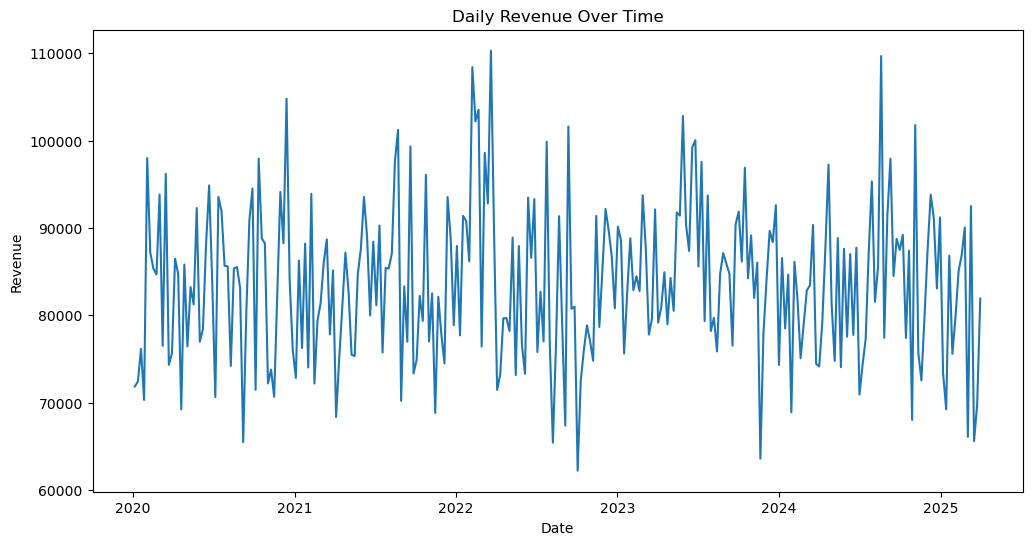

In [23]:
# Visualizing daily revenue over time
plt.figure(figsize=(12,6))

sns.lineplot(data=daily_sales, x="Date", y="Revenue")
plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [29]:
# To Format float numbers to 0 decimal places

pd.set_option("display.float_format", "{:.0f}".format)

In [32]:
# Top 5 categories by total revenue

Total_Revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False).head(5)
Total_Revenue

Category
Vitamin       4300225
Mineral       4276108
Performance   2909702
Protein       2855492
Amino Acid    1464820
Name: Revenue, dtype: float64

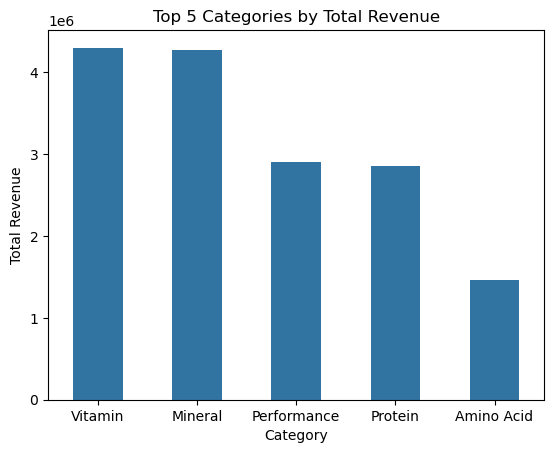

In [34]:
# Visualizing top 5 categories by total revenue

sns.barplot(x=Total_Revenue.index, y=Total_Revenue.values, width=0.5)
plt.title("Top 5 Categories by Total Revenue")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.show()

In [ ]:
# Minimum revenue by Location

Min_revenue_by_Location = df.groupby("Location")["Revenue"].min().sort_values(ascending=False)
Min_revenue_by_Location

Location
UK       1354
USA      1353
Canada   1284
Name: Revenue, dtype: float64

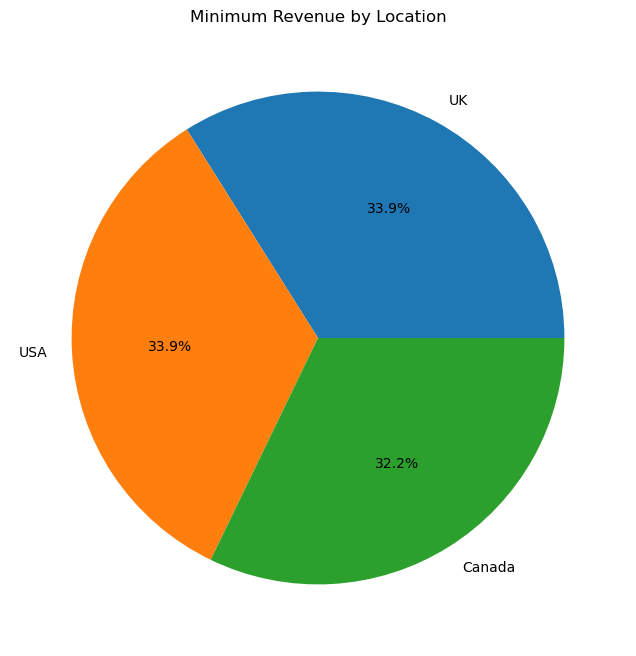

In [ ]:
# Visualizing Minimum revenue by Location in a pie chart

Min_revenue_by_Location.plot(kind="pie", autopct="%1.1f%%", figsize=(8,8), title="Minimum Revenue by Location")
plt.ylabel("")
plt.show()

In [54]:
# Revenue by Location and Platform

loc_platform = df.groupby(["Location", "Platform"])["Revenue"].sum().unstack().fillna(0)
loc_platform

Platform,Amazon,Walmart,iHerb
Location,,,
Canada,2613844,2518639,2716096
UK,2442671,2637066,2624223
USA,2612936,2232862,2514942


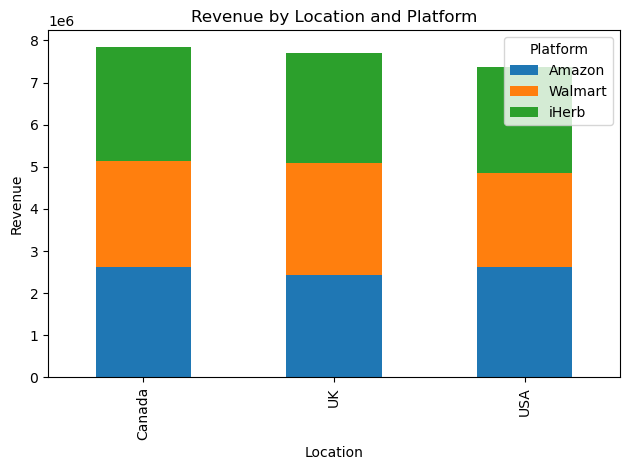

In [55]:
# Visualizing Revenue by Location and Platform

loc_platform.plot(kind="bar", stacked=True)
plt.title("Revenue by Location and Platform")
plt.xlabel("Location")
plt.ylabel("Revenue")
plt.legend(title="Platform")
plt.tight_layout()
plt.show()

In [ ]:
# Top 9 products by total revenue

top_products = df.groupby("Product Name")["Revenue"].sum().sort_values(ascending=False)
top_products.head(9)

Product Name
Biotin              1486799
Zinc                1482547
Pre-Workout         1477184
BCAA                1464820
Fish Oil            1451066
Green Tea Extract   1440900
Collagen Peptides   1433297
Creatine            1432518
Iron Supplement     1431582
Name: Revenue, dtype: float64

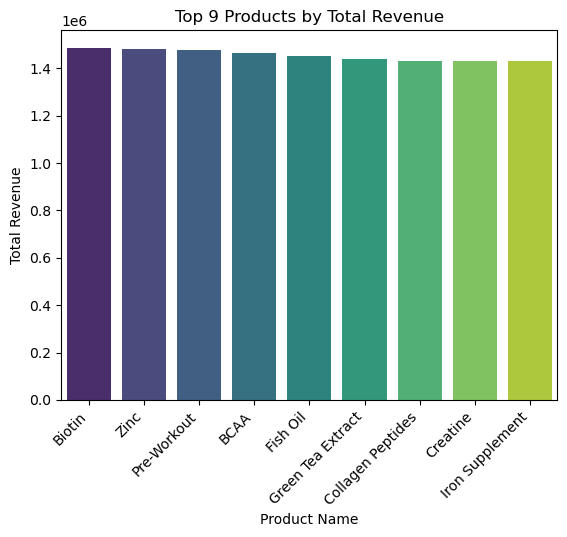

In [ ]:
# Visualizing Top 9 products by total revenue in a bar chart

sns.barplot(x=top_products.head(9).index, y=top_products.head(9).values, palette="viridis")
plt.title("Top 9 Products by Total Revenue")
plt.xlabel("Product Name")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.show()

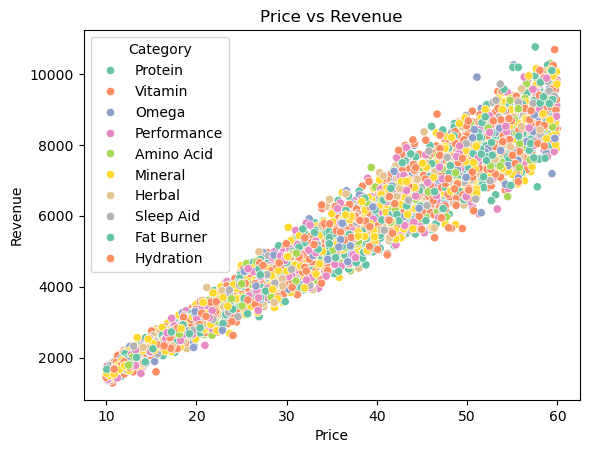

In [66]:
# Price vs Revenue by Category

sns.scatterplot(data=df, x="Price", y="Revenue", hue="Category", palette="Set2")
plt.title("Price vs Revenue")
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.show()

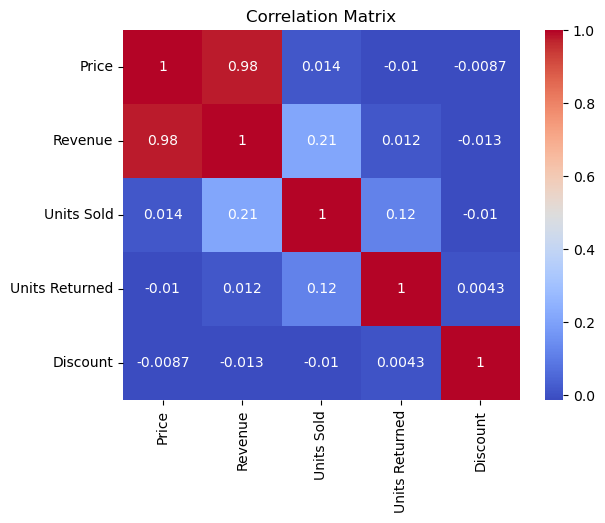

In [70]:
# Correlation matrix Of Price, Revenue, Units Sold, Units Returned, Discount....

corr = df[["Price", "Revenue", "Units Sold", "Units Returned","Discount"]].corr()

sns.heatmap(corr,annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [72]:
# Revenue Over Time by Location via Plotly

fig = px.line(df, x="Date", y="Revenue", color="Location", title="Revenue Over Time")
fig.show()

In [ ]:
# Calculating Net Revenue after accounting for returns

df["Net Revenue"] = df["Revenue"] - (df["Units Returned"] * df["Price"])
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Return Rate,Net Revenue
0,2020-01-06,Whey Protein,Protein,143,32,4573,0,2,Canada,Walmart,0,4509
1,2020-01-06,Vitamin C,Vitamin,139,43,5909,0,0,UK,Amazon,0,5909
2,2020-01-06,Fish Oil,Omega,161,13,2079,0,0,Canada,Amazon,0,2079
3,2020-01-06,Multivitamin,Vitamin,140,16,2250,0,0,Canada,Walmart,0,2250
4,2020-01-06,Pre-Workout,Performance,157,35,5569,0,3,Canada,iHerb,0,5462


In [ ]:
# Profit by Category

category_profit = df.groupby("Category")["Net Revenue"].sum().sort_values(ascending=False)
category_profit

Category
Vitamin       4255337
Mineral       4233108
Performance   2879997
Protein       2827040
Amino Acid    1449514
Omega         1436916
Fat Burner    1426130
Hydration     1396779
Herbal        1392349
Sleep Aid     1383402
Name: Net Revenue, dtype: float64

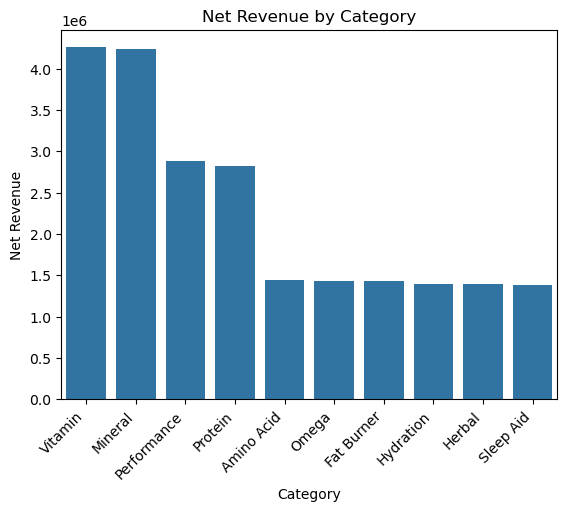

In [77]:
# Visualizing Net Revenue by Category

sns.barplot(x=category_profit.index, y=category_profit.values)
plt.title("Net Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
# Yearly Sales Aggregation

df["Yearly"] = df["Date"].dt.year
yearly_sales = df.groupby("Yearly").agg({
    "Price" : "sum",
    "Revenue": "sum",
    "Units Sold": "sum",
    "Units Returned":"sum"}).reset_index()

In [94]:


yearly_sales["Yearly"] = yearly_sales["Yearly"].astype(str)
yearly_sales

,Yearly,Price,Revenue,Units Sold,Units Returned
0,2020,28891,4323393,124657,1282
1,2021,28616,4294248,124701,1251
2,2022,29023,4372809,125167,1241
3,2023,29718,4470871,125038,1278
4,2024,29411,4429367,127707,1332
5,2025,6822,1022592,31208,330


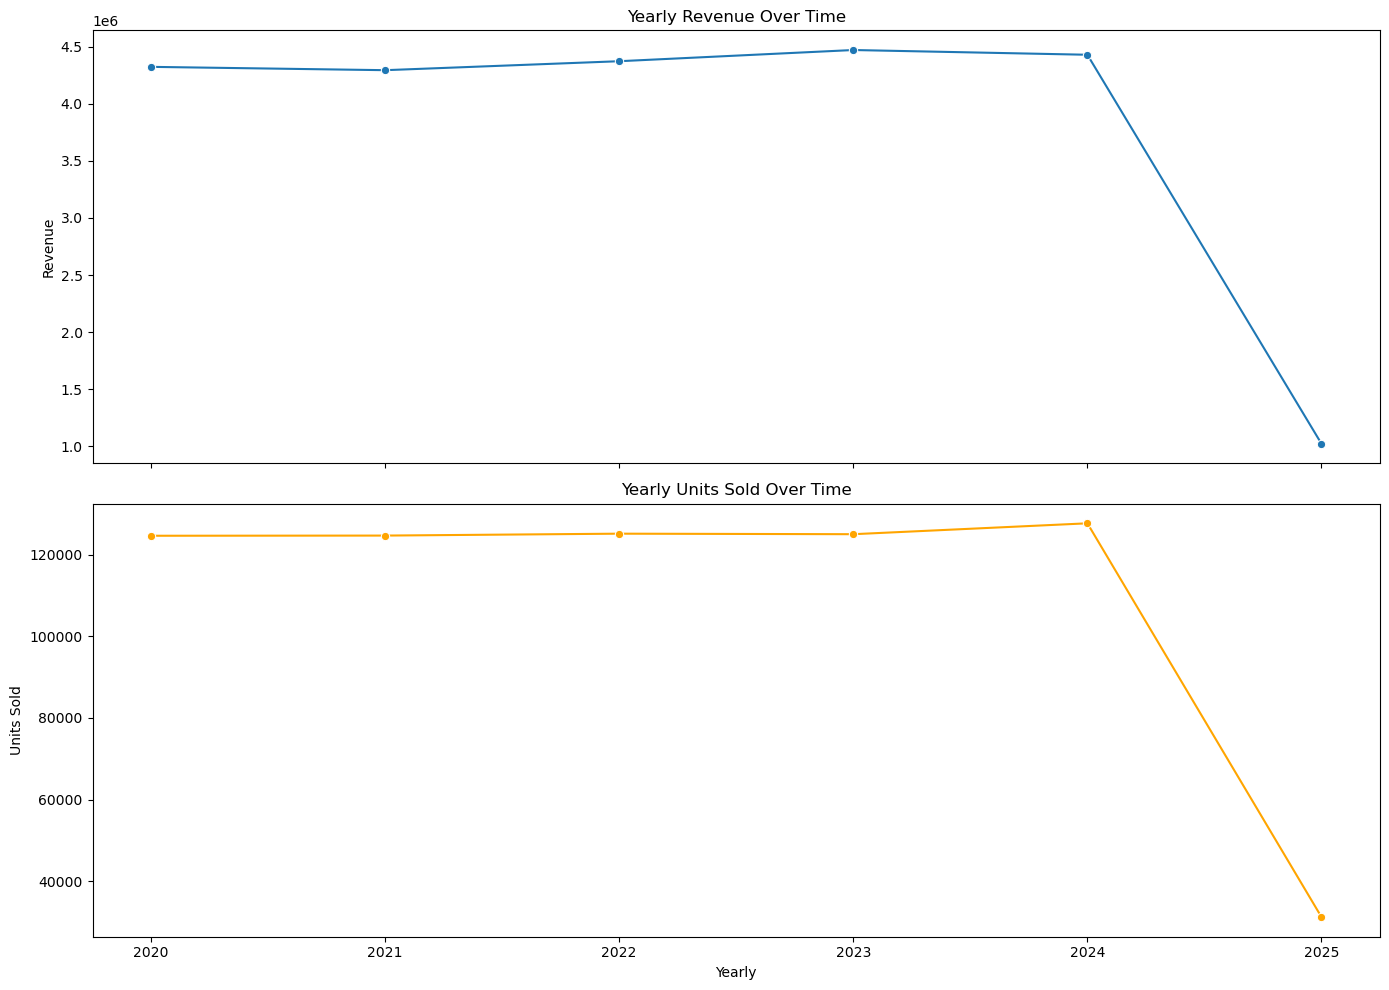

In [ ]:
# Visualizing Yearly Revenue and Units Sold Over Time

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14,10))

sns.lineplot(data=yearly_sales, x="Yearly", y="Revenue", marker="o", ax=axes[0])
axes[0].set_title("Yearly Revenue Over Time")

sns.lineplot(data=yearly_sales, x="Yearly", y="Units Sold", marker="o", ax=axes[1], color="orange")
axes[1].set_title("Yearly Units Sold Over Time")


plt.tight_layout()
plt.show()

In [44]:
df.columns

Index(['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue',
       'Discount', 'Units Returned', 'Location', 'Platform'],
      dtype='object')

In [ ]:
df['Location'].unique()

array(['Canada', 'UK', 'USA'], dtype=object)